In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('features2.csv')
y = df['label']
X = df.drop(['label', 'filepath', 'timestamp_year', 'timestamp_is_zero'], axis=1) #

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
train_data = lgb.Dataset(data=X_train, label=y_train)
test_data = lgb.Dataset(data=X_test, label=y_test, reference=train_data) 

In [5]:
params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,          # default, constrains tree complexity
    "min_child_samples": 30,   # require more samples per leaf
    "lambda_l1": 0.1,          # L1 regularisation
    "lambda_l2": 0.1,          # L2 regularisation
    "feature_fraction": 0.8,   # use 80% of features per tree (adds randomness)
    "bagging_fraction": 0.8,   # use 80% of data per tree
    "bagging_freq": 5,
}

In [6]:
booster = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=100,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.log_evaluation(period=10),
               lgb.early_stopping(stopping_rounds=50)] 
)

[LightGBM] [Info] Number of positive: 703, number of negative: 758
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2260
[LightGBM] [Info] Number of data points in the train set: 1461, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481177 -> initscore=-0.075326
[LightGBM] [Info] Start training from score -0.075326
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

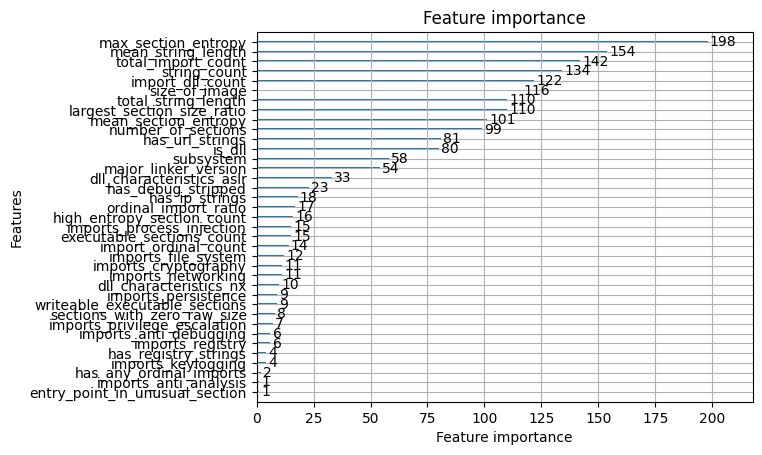

In [7]:
lgb.plot_importance(booster, importance_type='split', max_num_features=50)

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba = booster.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['benign', 'malicious']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      benign       0.94      0.96      0.95       190
   malicious       0.95      0.93      0.94       176

    accuracy                           0.95       366
   macro avg       0.95      0.94      0.95       366
weighted avg       0.95      0.95      0.95       366

[[182   8]
 [ 12 164]]


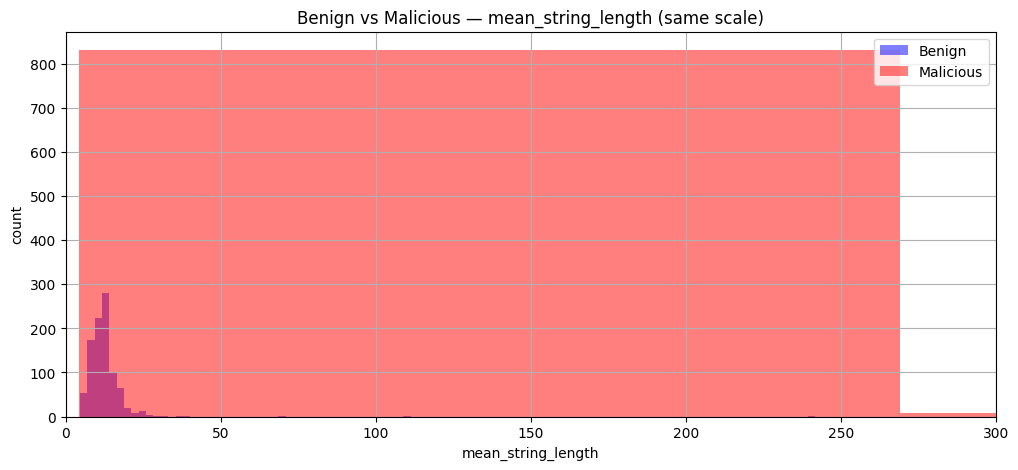

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

df[df.label == 0]['mean_string_length'].hist(
    bins=100, ax=ax, alpha=0.5, label='Benign', color='blue'
)
df[df.label == 1]['mean_string_length'].hist(
    bins=100, ax=ax, alpha=0.5, label='Malicious', color='red'
)

ax.set_xlim(0, 300) 
ax.legend()
ax.set_xlabel('mean_string_length')
ax.set_ylabel('count')
ax.set_title('Benign vs Malicious — mean_string_length (same scale)')
plt.show()

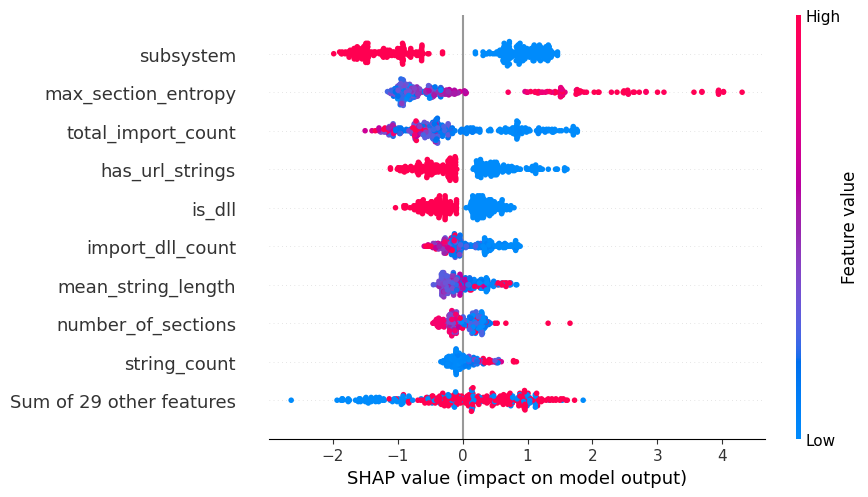

In [10]:
import shap

shap.initjs()
explainer = shap.Explainer(booster)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

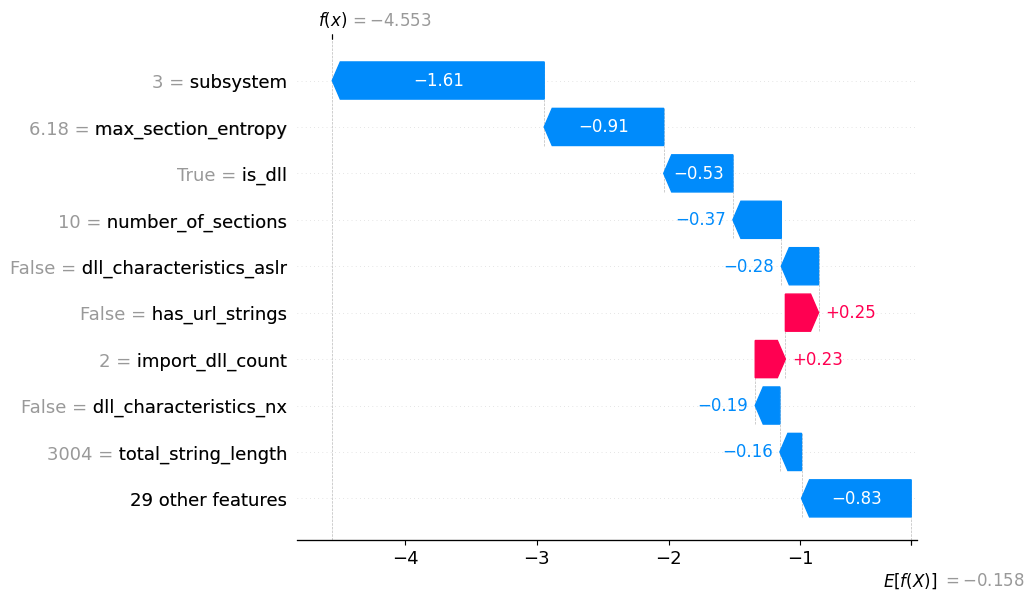

In [ ]:
shap.plots.waterfall(shap_values[5])

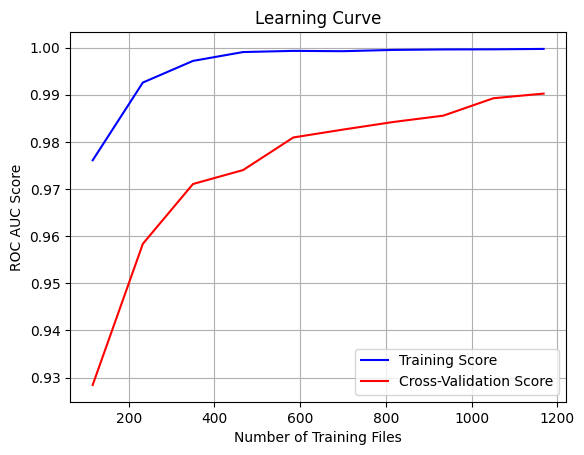

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np
from lightgbm import LGBMClassifier

clf = LGBMClassifier(**params)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=clf, 
    X=X_train, 
    y=y_train, 
    cv=5, 
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score", color='blue')
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color='red')
plt.title("Learning Curve")
plt.xlabel("Number of Training Files")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()